In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp
from pulp import LpProblem, LpMinimize, LpMaximize
import geopy.distance
import warnings
import geopandas as gpd
import cartopy.io.shapereader as shpreader

warnings.filterwarnings("ignore")

np.random.seed(42)

In [203]:
df_constraints = pd.read_excel("data/constraints.xlsx")
print(df_constraints.head())

  Constraint Type Source Destination
0         PMP-GDC   PLLU        USNE
1         PMP-GDC   PLLU        USSA
2         PMP-GDC   USAM        PLWA
3         PMP-GDC   USAM        ESMA
4         PMP-GDC   KRCH        USNE


In [204]:
df_constraints["Constraint Type"].unique() # 2 types of constraints

array(['PMP-GDC', 'GDC-WHS'], dtype=object)

In [205]:
df_demand = pd.read_excel("data/demand.xlsx")
print(df_demand.head())

  Country_Code   Unit Demand
0           AR  9.545572e+05
1           AT  3.370552e+06
2           AU  3.321179e+06
3           BE  4.993605e+06
4           BR  2.478707e+06


In [206]:
df_distribution = pd.read_excel("data/distribution.xlsx")
print(df_distribution.head())

  Site Code PRD Site Code GDC  Unit Distribution  Transfer cost per unit
0          PLLU          USNE           10949933                0.076424
1          PLLU          USSA                  0                0.313274
2          PLLU          PLWA            8411057                0.430141
3          PLLU          ESMA            2457791                0.149379
4          PLLU          ARBU                  0                0.449957


In [207]:
df_distribution["Site Code PRD"].unique()

array(['PLLU', 'USAM', 'KRCH', 'TRME'], dtype=object)

In [208]:
df_distribution["Site Code GDC"].unique()

array(['USNE', 'USSA', 'PLWA', 'ESMA', 'ARBU', 'CNBE', 'JPTO', 'INMU'],
      dtype=object)

In [209]:
df_location = pd.read_excel("data/locations.xlsx")
print(df_location.head())

  Type        Country Country_code Site_code       City      X_cord     Y_cord
0  PMP         Poland           PL      PLLU     Lublin   22.580737  51.276011
1  PMP  United States           US      USAM   Amarillo -102.851814  32.957891
2  PMP    South Korea           KR      KRCH     Chinju  128.107621  35.179982
3  PMP         Turkey           TR      TRME  Merkezköy   40.009251  40.832193
4  GDC            USA           US      USNE   New York  -73.935242  40.730610


In [210]:
df_location.loc[df_location["Site_code"] == "PLLU", :] # codes - unique ids

,Type,Country,Country_code,Site_code,City,X_cord,Y_cord
0,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011


In [211]:
df_location["Type"].unique() # production plant (PMP) -> distribution hub (GDC) -> warehouse (WHS) -> market (MKT)

array(['PMP', 'GDC', 'WHS', 'MKT'], dtype=object)

In [212]:
df_prices = pd.read_excel("data/prices.xlsx")
print(df_prices.head())

  Country_Code  Price per Unit in USD
0           AR                   3.53
1           AT                   4.43
2           AU                   4.25
3           BE                   4.32
4           BR                   4.23


In [213]:
df_production = pd.read_excel("data/production.xlsx")
print(df_production.head())

         Country Country_code Site Code  Unit Production
0         Poland           PL      PLLU         37298613
1  United States           US      USAM         41134963
2    South Korea           KR      KRCH         24640961
3         Turkey           TR      TRME         40168561


## Task 1

In [214]:
df_type = df_location[["Type", "Site_code"]]
df_distribution1 = pd.merge(df_distribution, df_type, left_on="Site Code PRD", right_on="Site_code", how="left", suffixes=("_src", "_dst"))
pd.merge(df_distribution1, df_type, left_on="Site Code GDC", right_on="Site_code", how="left", suffixes=("_src", "_dst"))
# df_distribution contains only info about transfer from PMP to GDC

,Site Code PRD,Site Code GDC,Unit Distribution,Transfer cost per unit,Type_src,Site_code_src,Type_dst,Site_code_dst
0,PLLU,USNE,10949933,0.076424,PMP,PLLU,GDC,USNE
1,PLLU,USSA,0,0.313274,PMP,PLLU,GDC,USSA
2,PLLU,PLWA,8411057,0.430141,PMP,PLLU,GDC,PLWA
3,PLLU,ESMA,2457791,0.149379,PMP,PLLU,GDC,ESMA
4,PLLU,ARBU,0,0.449957,PMP,PLLU,GDC,ARBU
5,PLLU,CNBE,4131069,0.558353,PMP,PLLU,GDC,CNBE
6,PLLU,JPTO,0,0.329165,PMP,PLLU,GDC,JPTO
7,PLLU,INMU,11348763,0.113696,PMP,PLLU,GDC,INMU
8,USAM,USNE,3125827,0.228482,PMP,USAM,GDC,USNE
9,USAM,USSA,432765,0.589694,PMP,USAM,GDC,USSA


In [215]:
# Calculate the Cost of Supply from Manufacturing to Distribution.

supply_cost = np.sum(df_distribution["Transfer cost per unit"] * df_distribution["Unit Distribution"])
print(f"Cost of Supply from Manufacturing to Distribution: {supply_cost:,.2f}")

Cost of Supply from Manufacturing to Distribution: 58,714,245.92


## Task 2

In [216]:
# Calculate the Optimal Cost from Manufacturing to Distribution if the cost is 0.1 USD per Unit per 1000 km.

# data preparation (joining coords)
df_coord = df_location[["Site_code", "X_cord", "Y_cord"]]
df_distribution1 = pd.merge(df_distribution, df_coord, left_on="Site Code PRD", right_on="Site_code", how="left", suffixes=("_src", "_dst"))
df_distribution2 = pd.merge(df_distribution1, df_coord, left_on="Site Code GDC", right_on="Site_code", how="left", suffixes=("_src", "_dst"))

In [217]:
# computing distance in km
df_distribution2["Distance"] = df_distribution2.apply(lambda x: geopy.distance.geodesic((x["Y_cord_src"], x["X_cord_src"]), (x["Y_cord_dst"], x["X_cord_dst"])).km, axis=1)

In [218]:
# adding number of produced units

df_distribution3 = pd.merge(df_distribution2, df_production, left_on="Site Code PRD", right_on="Site Code", how="left")
df_distribution3

,Site Code PRD,Site Code GDC,Unit Distribution,Transfer cost per unit,Site_code_src,X_cord_src,Y_cord_src,Site_code_dst,X_cord_dst,Y_cord_dst,Distance,Country,Country_code,Site Code,Unit Production
0,PLLU,USNE,10949933,0.076424,PLLU,22.580737,51.276011,USNE,-73.935242,40.730610,7015.250157,Poland,PL,PLLU,37298613
1,PLLU,USSA,0,0.313274,PLLU,22.580737,51.276011,USSA,-122.431297,37.773972,9567.836625,Poland,PL,PLLU,37298613
2,PLLU,PLWA,8411057,0.430141,PLLU,22.580737,51.276011,PLWA,21.012229,52.229676,151.620282,Poland,PL,PLLU,37298613
3,PLLU,ESMA,2457791,0.149379,PLLU,22.580737,51.276011,ESMA,-3.703790,40.416775,2352.708403,Poland,PL,PLLU,37298613
4,PLLU,ARBU,0,0.449957,PLLU,22.580737,51.276011,ARBU,-58.381559,-34.603684,12349.054237,Poland,PL,PLLU,37298613
5,PLLU,CNBE,4131069,0.558353,PLLU,22.580737,51.276011,CNBE,116.407390,39.904200,6919.960368,Poland,PL,PLLU,37298613
6,PLLU,JPTO,0,0.329165,PLLU,22.580737,51.276011,JPTO,139.691711,35.689487,8592.112426,Poland,PL,PLLU,37298613
7,PLLU,INMU,11348763,0.113696,PLLU,22.580737,51.276011,INMU,72.877426,19.076090,5646.060069,Poland,PL,PLLU,37298613
8,USAM,USNE,3125827,0.228482,USAM,-102.851814,32.957891,USNE,-73.935242,40.730610,2705.018639,United States,US,USAM,41134963
9,USAM,USSA,432765,0.589694,USAM,-102.851814,32.957891,USSA,-122.431297,37.773972,1853.814176,United States,US,USAM,41134963


In [219]:
model = LpProblem("DistributionTask", LpMinimize)

d = pulp.LpVariable.dicts(
    "distribution",
    ((row["Site Code PRD"], row["Site Code GDC"]) for _, row in df_distribution3.iterrows()),
    lowBound=0,
    cat='Integer'
)



cost = pulp.lpSum(
    d[row["Site Code PRD"], row["Site Code GDC"]] * 0.1 * row["Distance"] / 1000
    for _, row in df_distribution3.iterrows()
)

# objective function
model += cost

# constraints

# we must distribute all produced units
for site_code in df_distribution3["Site Code PRD"].unique():
    model += pulp.lpSum(
        d[row["Site Code PRD"], row["Site Code GDC"]]
        for _, row in df_distribution3.loc[df_distribution3["Site Code PRD"] == site_code, :].iterrows()
    ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()

# solving the problem
model.solve()

1

In [220]:
opt_cost = pulp.value(model.objective)
print(f"Optimal Cost of Supply from Manufacturing to Distribution: {opt_cost:,.2f}")

Optimal Cost of Supply from Manufacturing to Distribution: 18,499,916.57


## Task 3

In [221]:
# Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse if the cost is 0.1 USD per Unit per 1000 km.

df_pmp = df_location.loc[df_location["Type"] == "PMP", :]
df_gdc = df_location.loc[df_location["Type"] == "GDC", :]
df_whs = df_location.loc[df_location["Type"] == "WHS", :]

# adding index to make all combinations
df_pmp["id"] = 1
df_gdc["id"] = 1
df_whs["id"] = 1

df_dist = pd.merge(df_pmp, df_gdc, on="id", how="inner", suffixes=("_pmp", "_gdc"))
df_dist = pd.merge(df_dist, df_whs, on="id", how="inner", suffixes=("", "_whs"))

df_dist

,Type_pmp,Country_pmp,Country_code_pmp,Site_code_pmp,City_pmp,X_cord_pmp,Y_cord_pmp,id,Type_gdc,Country_gdc,...,City_gdc,X_cord_gdc,Y_cord_gdc,Type,Country,Country_code,Site_code,City,X_cord,Y_cord
0,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,New York,-73.935242,40.73061,WHS,Angola,AO,AOWH,Nzeto,12.868741,-7.226946
1,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,New York,-73.935242,40.73061,WHS,Argentina,AR,ARWH,Herrera,-58.373477,-34.655808
2,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,New York,-73.935242,40.73061,WHS,Bosnia and Herzegovina,BA,BAWH,Dubravica,18.117323,44.441036
3,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,New York,-73.935242,40.73061,WHS,Brazil,BR,BRWH,Osvaldo Cruz,-50.879763,-21.797225
4,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,New York,-73.935242,40.73061,WHS,Belize,BZ,BZWH,Punta Gorda,-88.809491,16.098935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Mumbai,72.877426,19.07609,WHS,Ukraine,UA,UAWH,Urzuf,37.104593,46.912552
1276,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Mumbai,72.877426,19.07609,WHS,Uganda,UG,UGWH,Namayingo,33.751772,-0.280357
1277,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Mumbai,72.877426,19.07609,WHS,United States,US,USWH,Rochester,-77.612083,43.153975
1278,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Mumbai,72.877426,19.07609,WHS,Venezuela,VE,VEWH,Aroa,-68.892856,10.431209


In [222]:
df_dist["Distance1"] = df_dist.apply(lambda x: geopy.distance.geodesic((x["Y_cord_pmp"], x["X_cord_pmp"]), (x["Y_cord_gdc"], x["X_cord_gdc"])).km, axis=1)

In [223]:
df_dist["Distance2"] = df_dist.apply(lambda x: geopy.distance.geodesic((x["Y_cord_gdc"], x["X_cord_gdc"]), (x["Y_cord"], x["X_cord"])).km, axis=1)

In [224]:
df_dist["Distance"] = df_dist["Distance1"] + df_dist["Distance2"]

In [225]:
len(df_dist) == len(df_pmp) * len(df_gdc) * len(df_whs)

True

In [226]:
# some paths are duplicated (but valid, different distances)
df_dist.loc[(df_dist.Site_code_pmp=="PLLU") & (df_dist.Site_code_gdc=="CNBE") & (df_dist.Site_code=="CNWH"), :]

,Type_pmp,Country_pmp,Country_code_pmp,Site_code_pmp,City_pmp,X_cord_pmp,Y_cord_pmp,id,Type_gdc,Country_gdc,...,Type,Country,Country_code,Site_code,City,X_cord,Y_cord,Distance1,Distance2,Distance
205,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,China,...,WHS,China,CN,CNWH,Zhoupu,121.574951,31.114301,6919.960368,1081.540729,8001.501097
206,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,China,...,WHS,China,CN,CNWH,Nanxia,106.158094,37.198731,6919.960368,941.895658,7861.856025


In [227]:
model = LpProblem("DistributionTask2", LpMinimize)

d = pulp.LpVariable.dicts(
    "distribution",
    ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code"]) for index, row in df_dist.iterrows()),
    lowBound=0,
    cat='Integer'
)


cost = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code"]] * 0.1 * row["Distance"] / 1000
    for index, row in df_dist.iterrows()
)

# objective function
model += cost


# constraints

# we must distribute all produced units
for site_code in df_dist["Site_code_pmp"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code"]]
        for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
    ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()


# solving the problem
model.solve()

1

In [228]:
opt_cost = pulp.value(model.objective)
print(f"Optimal Cost of Supply from Manufacturing to Distribution to Warehouse: {opt_cost:,.2f}")

Optimal Cost of Supply from Manufacturing to Distribution to Warehouse: 29,288,755.99


## Task 4

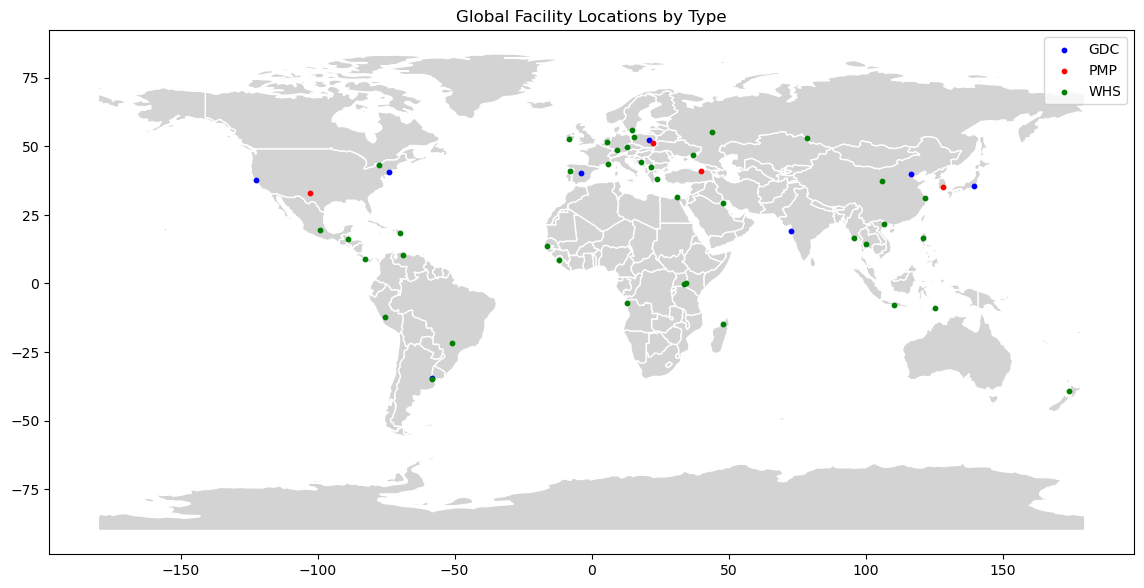

In [229]:
# Create a Python Code to generate a Map with the locations similar to the one in the page before

shpfilename = shpreader.natural_earth(
    resolution='110m',
    category='cultural',
    name='admin_0_countries'
)
world = gpd.read_file(shpfilename)

df_loc = df_location.loc[df_location.Type != "MKT", :]

gdf = gpd.GeoDataFrame(
    df_loc,
    geometry=gpd.points_from_xy(
        df_loc["X_cord"],  # longitude
        df_loc["Y_cord"]   # latitude
    ),
    crs="EPSG:4326"
)

type_colors = {
    "GDC": "blue",
    "WHS": "green",
    "PMP": "red"
}

fig, ax = plt.subplots(figsize=(14, 8))
world.plot(ax=ax, color="lightgray", edgecolor="white")

for t, subdf in gdf.groupby("Type"):
    ax.scatter(
        subdf["X_cord"],
        subdf["Y_cord"],
        label=t,
        s=10,
        color=type_colors.get(t, "black")
    )

ax.set_title("Global Facility Locations by Type")
ax.legend()
plt.show()

## Task 5

In [230]:
# Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse to Market if the cost is 0.1 USD per Unit per 1000 km.

df_pmp = df_location.loc[df_location["Type"] == "PMP", :]
df_gdc = df_location.loc[df_location["Type"] == "GDC", :]
df_whs = df_location.loc[df_location["Type"] == "WHS", :]
df_mkt = df_location.loc[df_location["Type"] == "MKT", :]

# adding index to make all combinations
df_pmp["id"] = 1
df_gdc["id"] = 1
df_whs["id"] = 1
df_mkt["id"] = 1

df_dist = pd.merge(df_pmp, df_gdc, on="id", how="inner", suffixes=("_pmp", "_gdc"))
df_dist = pd.merge(df_dist, df_whs, on="id", how="inner", suffixes=("", "_whs"))
df_dist = pd.merge(df_dist, df_mkt, on="id", how="inner", suffixes=("_whs", "_mkt"))

df_dist

,Type_pmp,Country_pmp,Country_code_pmp,Site_code_pmp,City_pmp,X_cord_pmp,Y_cord_pmp,id,Type_gdc,Country_gdc,...,City_whs,X_cord_whs,Y_cord_whs,Type_mkt,Country_mkt,Country_code_mkt,Site_code_mkt,City_mkt,X_cord_mkt,Y_cord_mkt
0,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,Nzeto,12.868741,-7.226946,MKT,Argentina,AR,AR,Buenos Aires,-34.0021,-64.0017
1,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,Nzeto,12.868741,-7.226946,MKT,Austria,AT,AR,Vienna,47.5162,14.5501
2,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,Nzeto,12.868741,-7.226946,MKT,Australia,AU,AR,Canberra,-25.2744,133.7751
3,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,Nzeto,12.868741,-7.226946,MKT,Belgium,BE,AR,Brussels,50.8503,4.3517
4,PMP,Poland,PL,PLLU,Lublin,22.580737,51.276011,1,GDC,USA,...,Nzeto,12.868741,-7.226946,MKT,Brazil,BR,AR,Brasília,-14.2350,-51.9253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62715,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Thành Phố Lạng Sơn,106.761519,21.853708,MKT,Turkey,TR,AR,Ankara,38.9637,35.2433
62716,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Thành Phố Lạng Sơn,106.761519,21.853708,MKT,Ukraine,UA,AR,Kyiv,48.3794,31.1656
62717,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Thành Phố Lạng Sơn,106.761519,21.853708,MKT,United States of America,US,AR,Washington,37.0902,-95.7129
62718,PMP,Turkey,TR,TRME,Merkezköy,40.009251,40.832193,1,GDC,India,...,Thành Phố Lạng Sơn,106.761519,21.853708,MKT,Vietnam,VN,AR,Hanoi,14.0583,108.2772


In [231]:
df_dist["Distance1"] = df_dist.apply(
    lambda x: geopy.distance.geodesic((x["Y_cord_pmp"], x["X_cord_pmp"]), (x["Y_cord_gdc"], x["X_cord_gdc"])).km,
    axis=1)

In [232]:
df_dist["Distance2"] = df_dist.apply(
    lambda x: geopy.distance.geodesic((x["Y_cord_gdc"], x["X_cord_gdc"]), (x["Y_cord_whs"], x["X_cord_whs"])).km, axis=1)

In [233]:
df_dist["Distance3"] = df_dist.apply(lambda x: geopy.distance.geodesic((x["Y_cord_whs"], x["X_cord_whs"]), (x["X_cord_mkt"], x["Y_cord_mkt"])).km, axis=1) # it works only if swapped

In [234]:
df_dist["Distance"] = df_dist["Distance1"] + df_dist["Distance2"] + df_dist["Distance3"]
len(df_dist) == len(df_pmp) * len(df_gdc) * len(df_whs) * len(df_mkt)

True

In [235]:
model = LpProblem("DistributionTask3", LpMinimize)

d = pulp.LpVariable.dicts(
    "distribution",
    ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]) for index, row in df_dist.iterrows()),
    lowBound=0,
    cat='Integer'
)


cost = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * 0.1 * row["Distance"] / 1000
    for index, row in df_dist.iterrows()
)

# objective function
model += cost


# constraints

# we must distribute all produced units
for site_code in df_dist["Site_code_pmp"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
    ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()

# solving the problem
model.solve()

1

In [236]:
opt_cost = pulp.value(model.objective)
print(f"Optimal Cost of Supply from Manufacturing to Distribution to Warehouse to Market: {opt_cost:,.2f}")

Optimal Cost of Supply from Manufacturing to Distribution to Warehouse to Market: 39,054,110.73


 ## Task 6

In [237]:
# Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse to Market if the cost is 0.1 USD per Unit per 1000 km, and you need to cover the Market Demands.

model = LpProblem("DistributionTask4", LpMinimize)

d = pulp.LpVariable.dicts(
    "distribution",
    ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]) for index, row in df_dist.iterrows()),
    lowBound=0,
    cat='Integer'
)


cost = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * 0.1 * row["Distance"] / 1000
    for index, row in df_dist.iterrows()
)

# objective function
model += cost


# constraints

# we must distribute all produced units
for site_code in df_dist["Site_code_pmp"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
    ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()

# we want to cover market demands
for country_code in df_demand["Country_Code"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Country_code_mkt"] == country_code, :].iterrows()
    ) >= df_demand.loc[df_demand["Country_Code"] == country_code, "Unit Demand"].sum()

# solving the problem
model.solve()

1

In [238]:
opt_cost = pulp.value(model.objective)
print(f"Optimal Cost of Supply from Manufacturing to Distribution to Warehouse to Market covering market demands: {opt_cost:,.2f}")

Optimal Cost of Supply from Manufacturing to Distribution to Warehouse to Market covering market demands: 70,732,432.24


## Task 7

In [239]:
# Calculate the Optimal Cost of the Supply from Manufacturing to Distribution to Warehouse to Market if the cost is 0.1 USD per Unit per 1000 km, and you need to cover the Market Demands, and you cannot Shipped between the Source and Destinations Specified in File Shipment Constraints.

model = LpProblem("DistributionTask5", LpMinimize)

d = pulp.LpVariable.dicts(
    "distribution",
    ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]) for index, row in df_dist.iterrows()),
    lowBound=0,
    cat='Integer'
)


cost = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * 0.1 * row["Distance"] / 1000
    for index, row in df_dist.iterrows()
)

# objective function
model += cost


# constraints

# we must distribute all produced units
for site_code in df_dist["Site_code_pmp"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
    ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()

# we want to cover market demands
for country_code in df_demand["Country_Code"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Country_code_mkt"] == country_code, :].iterrows()
    ) >= df_demand.loc[df_demand["Country_Code"] == country_code, "Unit Demand"].sum()
    

# shipment constraints

# PMP-GDC
for _, row_con in df_constraints[df_constraints["Constraint Type"] == "PMP-GDC"].iterrows():
    src = row_con["Source"]
    dst = row_con["Destination"]
    df_dist_filtered = df_dist[(df_dist["Site_code_pmp"] == src) & (df_dist["Site_code_gdc"] == dst)]
    for index, row in df_dist_filtered.iterrows():
        model += d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] == 0
        
# GDC-WHS
for _, row_con in df_constraints[df_constraints["Constraint Type"] == "GDC-WHS"].iterrows():
    src = row_con["Source"]
    dst = row_con["Destination"]
    df_dist_filtered = df_dist[(df_dist["Site_code_gdc"] == src) & (df_dist["Site_code_whs"] == dst)]
    for index, row in df_dist_filtered.iterrows():
        model += d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] == 0


# solving the problem
model.solve()

1

In [240]:
opt_cost = pulp.value(model.objective)
print(f"Optimal Cost of Supply from Manufacturing to Distribution to Warehouse to Market covering market demands with blocked paths: {opt_cost:,.2f}")

Optimal Cost of Supply from Manufacturing to Distribution to Warehouse to Market covering market demands with blocked paths: 70,783,958.12


## Task 8

In [241]:
df_prices["Price per Unit in USD"]

0     3.53
1     4.43
2     4.25
3     4.32
4     4.23
5     3.77
6     3.63
7     4.49
8     3.75
9     3.78
10    3.82
11    4.15
12    4.43
13    3.56
14    3.92
15    3.83
16    3.69
17    4.43
18    4.35
19    4.00
20    4.14
21    4.03
22    4.29
23    4.00
24    3.93
25    3.64
26    4.19
27    4.48
28    3.64
29    3.51
30    3.62
31    4.34
32    3.67
33    4.19
34    4.25
35    4.43
36    4.33
37    3.69
38    4.19
39    3.77
40    4.36
41    3.98
42    3.99
43    3.57
44    4.05
45    4.07
46    3.56
47    3.89
48    3.90
Name: Price per Unit in USD, dtype: float64

In [242]:
# Without taking into account the Constraints calculate the Maximum Revenue, and the minimum Supply Costs, just taking into account that all production units arrives to Market, check if the Supply is the same.

model = LpProblem("DistributionTask6", LpMaximize) # maximize profit

d = pulp.LpVariable.dicts(
    "distribution",
    ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]) for index, row in df_dist.iterrows()),
    lowBound=0,
    cat='Integer'
)


cost = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * 0.1 * row["Distance"] / 1000
    for index, row in df_dist.iterrows()
)


income = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * row_prc["Price per Unit in USD"]
    for _, row_prc in df_prices.iterrows()
    for index, row in df_dist[df_dist["Country_code_mkt"] == row_prc["Country_Code"]].iterrows()
)


# objective function
model += income - cost


# constraints

# we must distribute all produced units
for site_code in df_dist["Site_code_pmp"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
    ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()

# solving the problem
model.solve()

1

In [243]:
opt_revenue = pulp.value(model.objective)
print(f"Optimal revenue: {opt_revenue:,.2f}")

Optimal revenue: 585,690,949.68


In [244]:
opt_cost = cost.value()
print(f"Minimum supply cost: {opt_cost:,.2f}")

Minimum supply cost: 45,018,891.97


In [245]:
supply = sum(d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]].varValue for index, row in df_dist.iterrows())
print(f"Supply with constraint to deliver all produced products: {supply:,.0f}")

Supply with constraint to deliver all produced products: 143,243,098


In [246]:
# Without taking into account the Constraints calculate the Maximum Revenue, and the minimum Supply Costs, just taking into account that all production units arrives to Market, check if the Supply is the same.

model = LpProblem("DistributionTask7", LpMaximize) # maximize profit

d = pulp.LpVariable.dicts(
    "distribution",
    ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]) for index, row in df_dist.iterrows()),
    lowBound=0,
    cat='Integer'
)


cost = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * 0.1 * row["Distance"] / 1000
    for index, row in df_dist.iterrows()
)


income = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * row_prc["Price per Unit in USD"]
    for _, row_prc in df_prices.iterrows()
    for index, row in df_dist[df_dist["Country_code_mkt"] == row_prc["Country_Code"]].iterrows()
)


# objective function
model += income - cost

# we don't have to distribute all products
for site_code in df_dist["Site_code_pmp"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
    ) <= df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()


# solving the problem
model.solve()

1

In [247]:
opt_revenue = pulp.value(model.objective)
print(f"Optimal revenue: {opt_revenue:,.2f}")

Optimal revenue: 585,690,949.68


In [248]:
supply = sum(d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]].varValue for index, row in df_dist.iterrows())
print(f"Supply with constraint to deliver all produced products: {supply:,.0f}") # the same values as before

Supply with constraint to deliver all produced products: 143,243,098


## Task 9

In [249]:
# Perform a Sensitivity Analysis: How does the total cost change if the transportation cost increases by 20%? Provide a graph of cost vs. transportation rate

# Without taking into account the Constraints calculate the Maximum Revenue, and the minimum Supply Costs, just taking into account that all production units arrives to Market, check if the Supply is the same.

def get_cost(transportation_rate=1):
    model = LpProblem("DistributionTask8", LpMaximize) # maximize profit
    
    d = pulp.LpVariable.dicts(
        "distribution",
        ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]) for index, row in df_dist.iterrows()),
        lowBound=0,
        cat='Integer'
    )
    
    cost = pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * 0.1 * transportation_rate * row["Distance"] / 1000
        for index, row in df_dist.iterrows()
    )
    
    
    income = pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * row_prc["Price per Unit in USD"]
        for _, row_prc in df_prices.iterrows()
        for index, row in df_dist[df_dist["Country_code_mkt"] == row_prc["Country_Code"]].iterrows()
    )
    
    
    # objective function
    model += income - cost
    
    
    # constraints
    
    # we must distribute all produced units
    for site_code in df_dist["Site_code_pmp"].unique():
        model += pulp.lpSum(
            d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
            for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
        ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()
    
    # solving the problem
    model.solve()
    
    return cost.value()

In [250]:
transportation_rate = 1.2
cost2 = get_cost(transportation_rate)

In [251]:
print(f"Current cost: {opt_cost:,.2f}")
print(f"Cost after transportation cost increased by 20%: {cost2:,.2f}")

Current cost: 45,018,891.97
Cost after transportation cost increased by 20%: 54,022,670.37


In [252]:
transportation_rates = np.linspace(0.2, 2, 19)
costs = []
for transportation_rate in transportation_rates:
    costs.append(get_cost(transportation_rate))

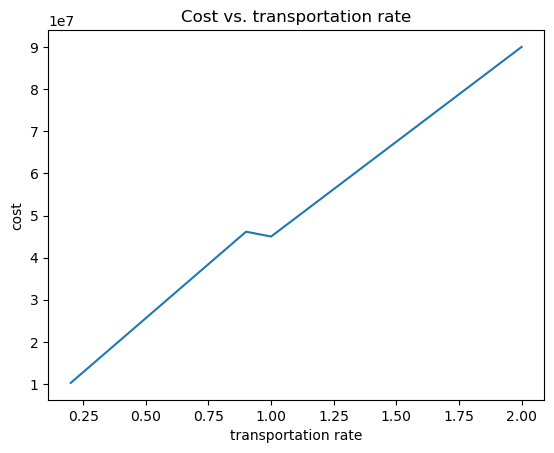

In [253]:
plt.plot(transportation_rates, costs)
plt.xlabel("transportation rate")
plt.ylabel("cost")
plt.title("Cost vs. transportation rate")
plt.show()

## Task 10

In [254]:
# Determine the Carbon Footprint of the optimized supply chain if emissions are 0.05 kg CO2 per Unit per 1000 km. Compare it with the baseline scenario.

carbon_footprint = sum(d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]].varValue * 0.05 * row["Distance"] for index, row in df_dist.iterrows())
print(f"Carbon footprint for optimal solution: {carbon_footprint:,.2f} kg")

Carbon footprint for optimal solution: 22,509,445,986.63 kg


In [255]:
# baseline

model = LpProblem("DistributionTask9", LpMinimize)

d = pulp.LpVariable.dicts(
    "distribution",
    ((index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]) for index, row in df_dist.iterrows()),
    lowBound=0,
    cat='Integer'
)


cost = pulp.lpSum(
    d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]] * 0.1 * row["Distance"] / 1000
    for index, row in df_dist.iterrows()
)

# objective function
model += cost

# constraints

# we must distribute all produced units
for site_code in df_dist["Site_code_pmp"].unique():
    model += pulp.lpSum(
        d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]]
        for index, row in df_dist.loc[df_dist["Site_code_pmp"] == site_code, :].iterrows()
    ) == df_production.loc[df_production["Site Code"] == site_code, "Unit Production"].sum()

# solving the problem
model.solve()

1

In [256]:
carbon_footprint = sum(d[index, row["Site_code_pmp"], row["Site_code_gdc"], row["Site_code_whs"], row["Site_code_mkt"]].varValue * 0.05 * row["Distance"] for index, row in df_dist.iterrows())
print(f"Carbon footprint for baseline solution: {carbon_footprint:,.2f} kg")

Carbon footprint for baseline solution: 19,527,055,365.42 kg
